### This notebook compute "E2. Number of irrigation water infrastructure exposed to climate hazards" indicator for the 27 basins of IKI Project

Spanish: Número de infraestructura hidráulica de riego expuesta a peligros climáticos

**Created:** 8/10/2025 by Serena Gilson (sgilson@rti.org) 

**Project #:** 0219481  

**Last modified:** 1/2/2026 by Sophia (sbakar@rti.org)

**Status:** Complete and loaded in SQLite database

**QA Status:** reviewed by  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Exposicion\Scripts_Exposure
 
**Inputs:**   Shapefile of COMIDs, downloaded hydraulic infrastructure information from SNIRH for each watershed, sum the total exposed by district, normalize the results of the number of infratructure exposed with the formula of maximum and minimum for all the districts that make up the watershed.

    1. Download de ANA: https://snirh.ana.gob.pe/ConsultaIDE/
    2. Shapefiles used and aggregated: 
        a. Datos ANA
            i. Pozos.shp
            ii. Bocatomas.sho
            iii. Presas.shp
            iv. CanalTrasvase.shp
            v. CanalLateral.shpCanalAduccion.shp
            vi. CanalDerivacion.shp
            vii. Embalses.shp
            viii. Acueducto.shp

Indicador óptimo: Número de infraestructura hidráulica de riego expuesta a peligros
climáticos
○ Descarga información espacial sobre la infraestructura hidráulica que se encuentra en la
cuenca de la plataforma del Sistema Nacional de Información de Recursos Hídricos
(SNIRH)38.
○ Suma el total de infraestructura hidráulica expuesta producto del paso anterior por distrito.
○ Normaliza los resultados del número de la infraestructura expuesta con la fórmula de
máximos y mínimos, entre todos los distritos que conforman la cuenca.
 
**Assumptions:** For our version of the methodology, we do not need to sum by district first since we are working with the shapefiles. 

**N/A Handling:** Sets COMIDs with 0 insfrastructure features as NaN.  

**Future work:** 
 
**Notes:**  
General methodology:  
1. Read in all structures datasets and format into a list.  
2. For each COMID, determine the number of features from each structures dataset by comparing geometry.  
3. Add feature count to total per COMID to determine the total number of infrastructure features.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'sgilson'
#user = 'nreynolds'
user = 'sbakar'
# FP: C:\Users\nreynolds\Research Triangle Institute\IKI Peru Project - General\Externo\PACA_Peru\Modelacion\Indicadores
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 202 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [ ]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#read in infrastructure shapefiles 

#read in pozos 
#pozos_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Pozos.shp'
#read in bocatomas 
#bocatomas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Bocatomas.shp'
#read in presas
#presas_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Presas.shp'
#read in canals 
#canals_tras_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalTrasvase.shp'
#canals_lat_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalLateral.shp'
#canals_ad_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalAduccion.shp'
#canals_der_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/CanalDerivacion.shp'
#read in reservoirs
#embalses_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/embalses_IKI.shp'
#read in aqueducts 
#aqueducts_shp = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/GIS/4_DEMANDAS_DEMANDS/Datos_ANA/Acueducto.shp'

# read in pozos 
# FP: C:\Users\nreynolds\Research Triangle Institute\IKI Peru Project - General\Externo\PACA_Peru\GIS\Datos_ANA
pozos_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\Datos_ANA\Pozos.shp"

# read in bocatomas 
bocatomas_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Bocatomas.shp"

# read in presas
# FP: C:\Users\nreynolds\Research Triangle Institute\IKI Peru Project - General\Externo\PACA_Peru\GIS\Datos_ANA
presas_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\Datos_ANA\Presas.shp"

# read in canals 
canals_tras_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\CanalTrasvase.shp"
canals_lat_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\CanalLateral.shp"
canals_ad_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\CanalAduccion.shp"
canals_der_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\CanalDerivacion.shp"

# read in reservoirs
embalses_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\embalses_IKI.shp"

# read in aqueducts 
aqueducts_shp = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\GIS\4_DEMANDAS_DEMANDS\Datos_ANA\Acueducto.shp"

In [5]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

# Ensure all infrastructure shapefiles have the same CRS as the subbasin shapefile
subbasins_crs = subbasins_gdf.crs  # Get the CRS of the subbasin shapefile

# Reproject infrastructure shapefiles to match the subbasin CRS
bocatomas_gdf = gpd.read_file(bocatomas_shp).to_crs(subbasins_crs)
pozos_gdf = gpd.read_file(pozos_shp).to_crs(subbasins_crs)
presas_gdf = gpd.read_file(presas_shp).to_crs(subbasins_crs)
aqueducts_gdf = gpd.read_file(aqueducts_shp).to_crs(subbasins_crs)
canals_tras_gdf = gpd.read_file(canals_tras_shp).to_crs(subbasins_crs)
canals_lat_gdf = gpd.read_file(canals_lat_shp).to_crs(subbasins_crs)
canals_ad_gdf = gpd.read_file(canals_ad_shp).to_crs(subbasins_crs)
canals_der_gdf = gpd.read_file(canals_der_shp).to_crs(subbasins_crs)
embalses_gdf = gpd.read_file(embalses_shp).to_crs(subbasins_crs)

# List of all infrastructure GeoDataFrames
infrastructure_gdfs = [
    bocatomas_gdf,
    canals_tras_gdf,
    canals_lat_gdf,
    canals_ad_gdf,
    canals_der_gdf,
    embalses_gdf,
    pozos_gdf,
    presas_gdf,     
    aqueducts_gdf
]


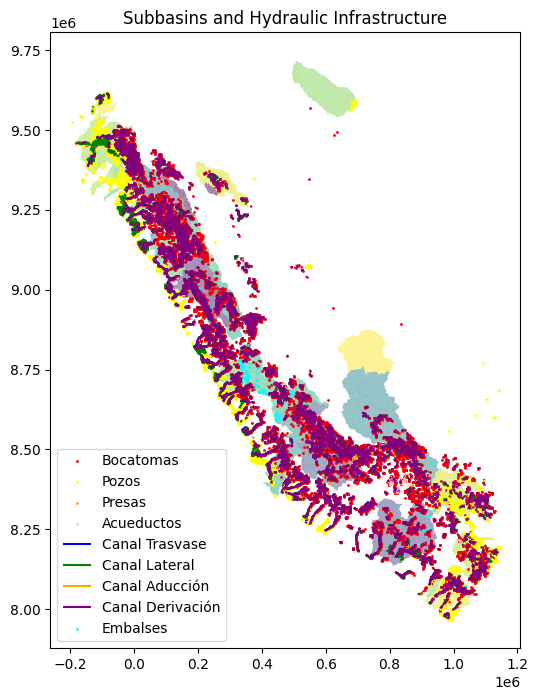

In [6]:
#PLOT TO VERIFY

# Plot subbasins and bocatomas on the same plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot subbasins
subbasins_gdf.plot(ax=ax, column='IDDIST', legend=True, cmap='viridis', alpha=0.5)

# Plot bocatomas
bocatomas_gdf.plot(ax=ax, color='red', markersize=1, label='Bocatomas')
pozos_gdf.plot(ax=ax, color='yellow', markersize=1, label='Pozos')
presas_gdf.plot(ax=ax, color='orange', markersize=1, label='Presas')
aqueducts_gdf.plot(ax=ax, color='pink', markersize=1, label='Acueductos')
canals_tras_gdf.plot(ax=ax, color='blue', markersize=1, label='Canal Trasvase')
canals_lat_gdf.plot(ax=ax, color='green', markersize=1, label='Canal Lateral')
canals_ad_gdf.plot(ax=ax, color='orange', markersize=1, label='Canal Aducción')
canals_der_gdf.plot(ax=ax, color='purple', markersize=1, label='Canal Derivación')
embalses_gdf.plot(ax=ax, color='cyan', markersize=1, label='Embalses')


# Add title and legend
plt.title('Subbasins and Hydraulic Infrastructure')
plt.legend()

# Show the plot
plt.show()

In [7]:
#COUNT INFRASTRUCTURE FEATURES PER SUBBASIN

# Initialize a dictionary to store counts
basin_feature_counts = {}

# Loop through each subbasin
for basin_id, basin_geometry in zip(subbasins_gdf['COMID'], subbasins_gdf.geometry):
    total_features = 0
    for infra_gdf in infrastructure_gdfs:
        # Count features within the basin
        features_in_basin = infra_gdf[infra_gdf.geometry.within(basin_geometry)].shape[0]
        total_features += features_in_basin
    basin_feature_counts[basin_id] = total_features

basin_feature_counts_df = pd.DataFrame(list(basin_feature_counts.items()), columns=['COMID', 'Feature_Count'])

# Display the results
print(basin_feature_counts_df)

# Merge the feature count DataFrame with the subbasins GeoDataFrame
subbasins_gdf = subbasins_gdf.merge(basin_feature_counts_df, left_on='COMID', right_on='COMID', how='left')
subbasins_gdf.loc[subbasins_gdf['Feature_Count'] == 0, 'Feature_Count'] = np.nan

print(f"NaN values in Feature_Count (no infrastructure): {subbasins_gdf['Feature_Count'].isna().sum()}")

          COMID  Feature_Count
0     311153600              4
1     310832400              4
2     310825700              1
3     310282400            430
4     308754600             25
...         ...            ...
3650  312029900             12
3651  312046300             30
3652  312066700             43
3653  320251000            282
3654  320254600            408

[3655 rows x 2 columns]
NaN values in Feature_Count (no infrastructure): 1850


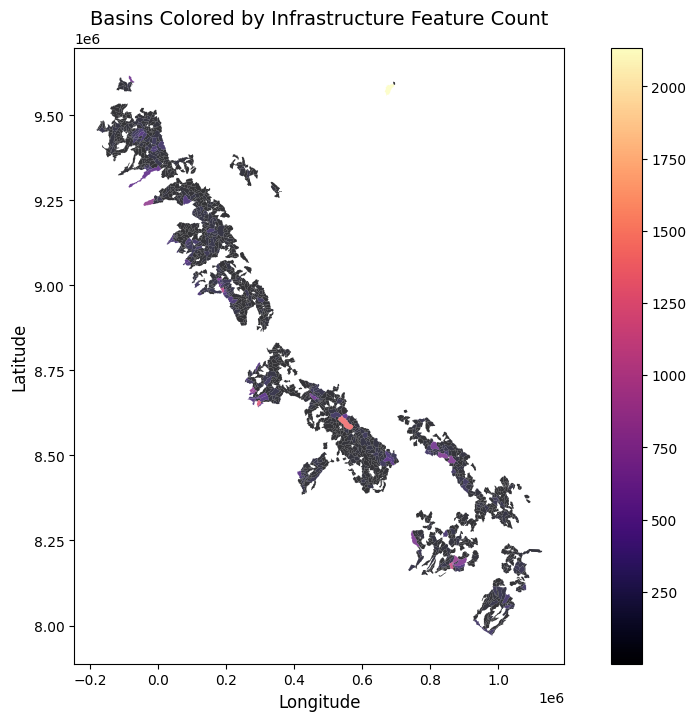

In [8]:
# Plot the basins colored by the feature count
fig, ax = plt.subplots(figsize=(12, 8))
subbasins_gdf.plot(ax=ax, column='Feature_Count', legend=True, cmap='magma', alpha=0.8)

# Add title and labels
plt.title('Basins Colored by Infrastructure Feature Count', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Show the plot
plt.show()

In [9]:
# insert results into the database 
insert_data= subbasins_gdf #COMID 
value_column= 'Feature_Count' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [10]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Feature_Count']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 202  Min: 0, Max: 3000

=== Values to be inserted (by scenario) ===
   index  Feature_Count
0    min            1.0
1    max         2134.0
2  count         1805.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [11]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()

### TEST FOR JUST ONE COMID TO ENSURE METHOD

C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  infra_within_basin.plot(ax=ax, markersize=10, label=label)
C:\Users\sgilson\AppData\Local\Temp\ipykernel_39204\3821138212.py:23: UserWarning: The GeoDataFr

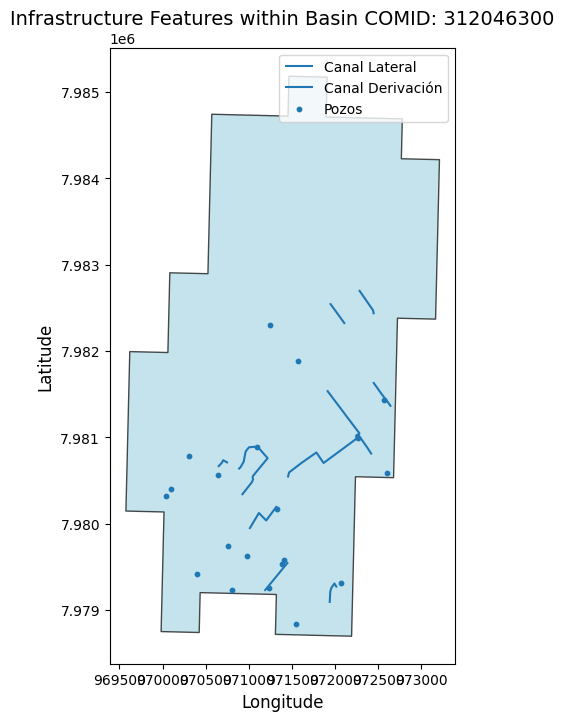

In [ ]:
import matplotlib.pyplot as plt

# Specify the COMID to plot
target_comid = 312046300  # Replace with the desired COMID

# Filter the subbasin for the target COMID
target_basin = subbasins_gdf[subbasins_gdf['COMID'] == target_comid]

# Initialize a plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the target subbasin
target_basin.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.7, label=f'Basin COMID: {target_comid}')

# Plot infrastructure features within the target subbasin
for infra_gdf, label in zip(infrastructure_gdfs, [
    'Bocatomas', 'Canal Trasvase', 'Canal Lateral', 'Canal Aducción', 
    'Canal Derivación', 'Embalses', 'Pozos', 'Presas', 'Acueductos'
]):
    infra_within_basin = infra_gdf[infra_gdf.geometry.within(target_basin.geometry.iloc[0])]
    infra_within_basin.plot(ax=ax, markersize=10, label=label)

# Add title, legend, and labels
plt.title(f'Infrastructure Features within Basin COMID: {target_comid}', fontsize=14)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend()

# Show the plot
plt.show()